Setup

In [1]:
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from time import time

import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TTF
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from IPython.display import clear_output


from dataloader import PH2DataLoader
from network import EncDec, UNet
from losses import bce_loss, dice_loss, focal_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


DataLoader

In [2]:
data_path = '/dtu/datasets1/02514/PH2_Dataset_images'

In [25]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.RandomVerticalFlip(p=0.5),
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 6
trainset = PH2DataLoader(transform=train_transform, data_path=data_path, train=True)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=3)

validationset = PH2DataLoader(transform=test_transform, data_path=data_path, validation=True)
validation_loader = DataLoader(validationset, batch_size=batch_size, shuffle=False, num_workers=3)

testset = PH2DataLoader(transform=test_transform, data_path=data_path)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)

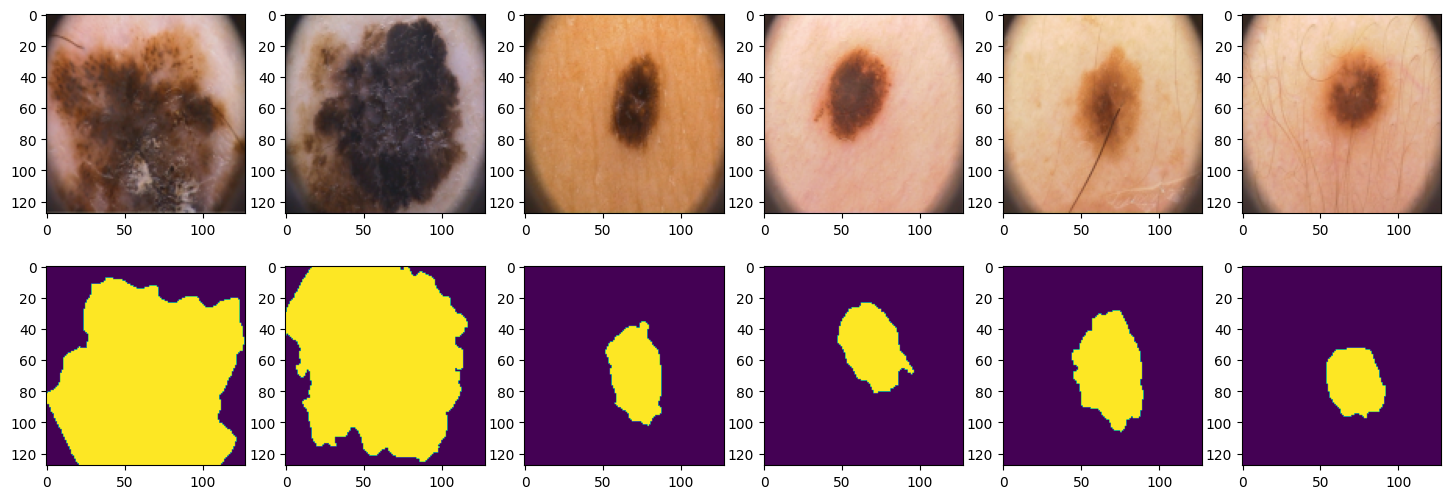

In [26]:
plt.rcParams['figure.figsize'] = [18, 6]

images, labels = next(iter(train_loader))

for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))

    plt.subplot(2, 6, i+7)
    plt.imshow(labels[i].squeeze())
plt.show()

# Train

In [5]:
def iou(target, prediction):
    intersection = torch.sum(torch.logical_and(target, prediction))
    union = torch.sum(torch.logical_or(target, prediction))
    return (intersection.item()/union.item())

def accuracy(TP, TN, FP, FN):
    return (TP + TN) / (TP + FP + TN +FN)

def sensitivity(TP, FN):
    return TP / (TP + FN)

def specificity(TN, FP):
    return TN / (FP + TN)

def dice(target, prediction):
    return (2 * torch.sum(torch.logical_and(target, prediction)) / (target.sum() + prediction.sum())).item()

In [6]:
def compute_confusion(target, prediction):
    TP = torch.sum(torch.logical_and(prediction == 1, target == 1))
    TN = torch.sum(torch.logical_and(prediction == 0, target == 0))
    FP = torch.sum(torch.logical_and(prediction == 1, target == 0))
    FN = torch.sum(torch.logical_and(prediction == 0, target == 1))
                
    return TP.item(), TN.item(), FP.item(), FN.item()

In [7]:
def train(model, opt, loss_fn, epochs, train_loader, test_loader):
    X_test, Y_test = next(iter(test_loader))
    out_dict = {              
                'train_loss': [],
                'train_iou': [],
                'train_accuracy': [],
                'train_sensitivity': [],
                'train_specificity': [],
                'train_dice': [],
        
                'validation_loss': [],
                'validation_iou': [],
                'validation_accuracy': [],
                'validation_sensitivity': [],
                'validation_specificity': [],
                'validation_dice': []
                }

    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        metrics = {
                    'iou': 0,
                    'accuracy': 0,
                    'sensitivity': 0,
                    'specificity': 0,
                    'dice': 0
                    }
        model.train()  # train mode
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred)  # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate metrics to show the user
            avg_loss += loss / len(train_loader)
            prediction = torch.where(F.sigmoid(Y_pred) > 0.5, 1, 0).detach().cpu()
            target = Y_batch.detach().cpu()
            
            TP, TN, FP, FN = compute_confusion(target, prediction)
            metrics['iou'] += iou(target, prediction) / len(train_loader)
            metrics['accuracy'] += accuracy(TP, TN, FP, FN) / len(train_loader)
            metrics['sensitivity'] += sensitivity(TP, FN) / len(train_loader)
            metrics['specificity'] += specificity(TN, FP) / len(train_loader)
            metrics['dice'] += dice(target, prediction) / len(train_loader)
            
        toc = time()
        out_dict["train_loss"].append(avg_loss.item())
        out_dict["train_iou"].append(metrics['iou'])
        out_dict["train_accuracy"].append(metrics['accuracy'])
        out_dict["train_sensitivity"].append(metrics['sensitivity'])
        out_dict["train_specificity"].append(metrics['specificity'])
        out_dict["train_dice"].append(metrics['dice'])
        print(' - Train loss: %f' % avg_loss)
        print(f"IOU is {metrics['iou']}, accuracy is {metrics['accuracy']}, sensitivity is {metrics['sensitivity']}, specificity is {metrics['specificity']}, dice is {metrics['dice']}")
        
        
        avg_loss = 0
        metrics = {
                    'iou': 0,
                    'accuracy': 0,
                    'sensitivity': 0,
                    'specificity': 0,
                    'dice': 0
                    }
        model.eval()  # testing mode
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            
            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred)  # forward-pass

            # calculate metrics to show the user
            avg_loss += loss / len(test_loader)
            prediction = torch.where(F.sigmoid(Y_pred) > 0.5, 1, 0).detach().cpu()
            target = Y_batch.detach().cpu()
            
            TP, TN, FP, FN = compute_confusion(target, prediction)
            metrics['iou'] += iou(target, prediction) / len(test_loader)
            metrics['accuracy'] += accuracy(TP, TN, FP, FN) / len(test_loader)
            metrics['sensitivity'] += sensitivity(TP, FN) / len(test_loader)
            metrics['specificity'] += specificity(TN, FP) / len(test_loader)
            metrics['dice'] += dice(target, prediction) / len(test_loader)
            
        toc = time()
        out_dict["validation_loss"].append(avg_loss.item())
        out_dict["validation_iou"].append(metrics['iou'])
        out_dict["validation_accuracy"].append(metrics['accuracy'])
        out_dict["validation_sensitivity"].append(metrics['sensitivity'])
        out_dict["validation_specificity"].append(metrics['specificity'])
        out_dict["validation_dice"].append(metrics['dice'])
        print(' - Validation loss: %f' % avg_loss)        
        
        # show intermediate results
        Y_hat = F.sigmoid(model(X_test.to(device))).detach().cpu()
        clear_output(wait=True)
        for k in range(6):
            plt.subplot(3, 6, k+1)
            plt.imshow(np.rollaxis(X_test[k].numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(3, 6, k+7)
            plt.imshow(Y_hat[k, 0], cmap='gray')
            plt.title('Output')
            plt.axis('off')
            
            plt.subplot(3, 6, k+13)
            plt.imshow(Y_test[k, 0].detach().cpu(), cmap='gray')
            plt.title('Ground truth')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()
        print(f"IOU is {metrics['iou']}, accuracy is {metrics['accuracy']}, sensitivity is {metrics['sensitivity']}, specificity is {metrics['specificity']}, dice is {metrics['dice']}")
        
        
    return out_dict

In [8]:
def predict(model, test_loader):
    out_dict = {'test_loss':[],              
                'test_iou': [],
                'test_accuracy': [],
                'test_sensitivity': [],
                'test_specificity': [],
                'test_dice': []
                }
    predictions = []
    targets = []
    
    metrics = {
                    'iou': 0,
                    'accuracy': 0,
                    'sensitivity': 0,
                    'specificity': 0,
                    'dice': 0
                    }
    
    model.eval()  # testing mode
    avg_loss = 0
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # calculate metrics to show the user
        Y_pred = F.sigmoid(model(X_batch.to(device))).detach().cpu()
        prediction = torch.where(Y_pred > 0.5, 1, 0).detach().cpu()
        target = Y_batch.detach().cpu()
            
        TP, TN, FP, FN = compute_confusion(target, prediction)
        metrics['iou'] += iou(target, prediction) / len(test_loader)
        metrics['accuracy'] += accuracy(TP, TN, FP, FN) / len(test_loader)
        metrics['sensitivity'] += sensitivity(TP, FN) / len(test_loader)
        metrics['specificity'] += specificity(TN, FP) / len(test_loader)
        metrics['dice'] += dice(target, prediction) / len(test_loader)
        
        predictions+=(prediction)
        targets+=(target)
        
        for k in range(6):
            plt.subplot(3, 6, k+1)
            plt.imshow(np.rollaxis(X_batch[k].detach().cpu().numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(3, 6, k+7)
            plt.imshow(prediction[k, 0], cmap='gray')
            plt.title('Output')
            plt.axis('off')
            
            plt.subplot(3, 6, k+13)
            plt.imshow(Y_batch[k, 0].detach().cpu(), cmap='gray')
            plt.title('Ground truth')
            plt.axis('off')
        plt.show()
            
    toc = time()
    out_dict["test_iou"].append(metrics['iou'])
    out_dict["test_accuracy"].append(metrics['accuracy'])
    out_dict["test_sensitivity"].append(metrics['sensitivity'])
    out_dict["test_specificity"].append(metrics['specificity'])
    out_dict["test_dice"].append(metrics['dice'])
    
    print('test iou: %f' % metrics['iou'])
    print('test accuracy: %f' % metrics['accuracy'])
    print("test sensitivity: %f" % metrics['sensitivity'])
    print("test specificity: %f" % metrics['specificity'])
    print("test dice: %f" % metrics['dice'])
        
    return predictions, targets, out_dict

# Baseline Model

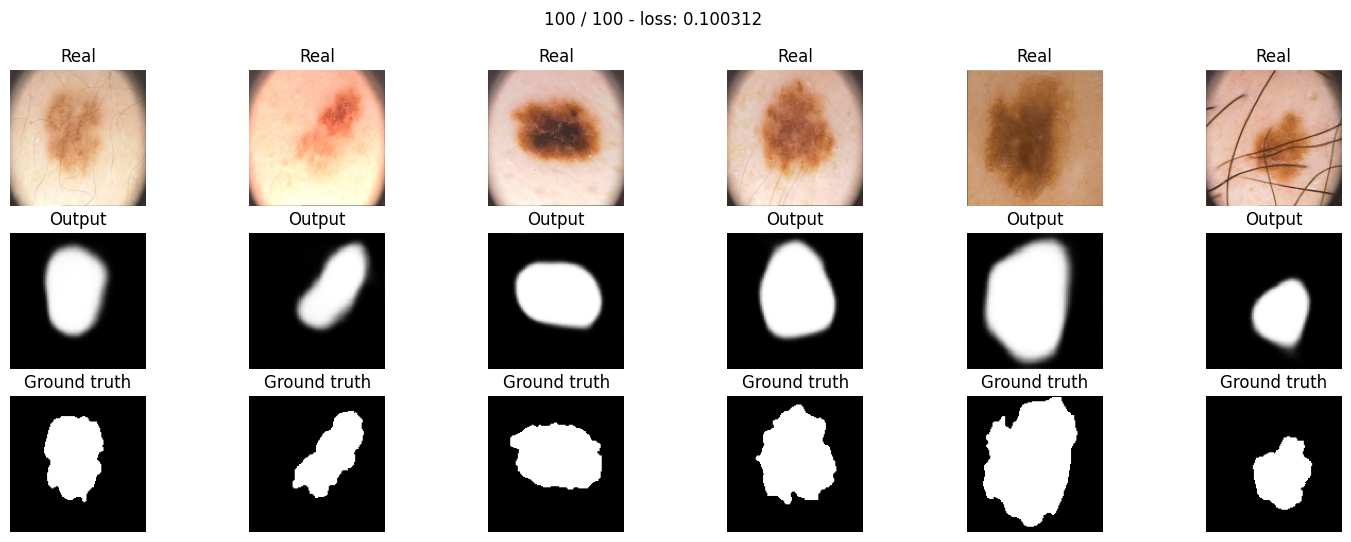

IOU is 0.8702448228569426, accuracy is 0.9620707194010416, sensitivity is 0.9094891577764015, specificity is 0.9816470594267237, dice is 0.9303986668586732


In [28]:
model = EncDec().to(device)
out_dict = train(model, optim.Adam(model.parameters(), lr=1e-4), bce_loss, 100, train_loader, validation_loader)

In [33]:
import json

with open('baseline_out_train.json', 'w') as fp:
    json.dump(out_dict, fp)

### Loss

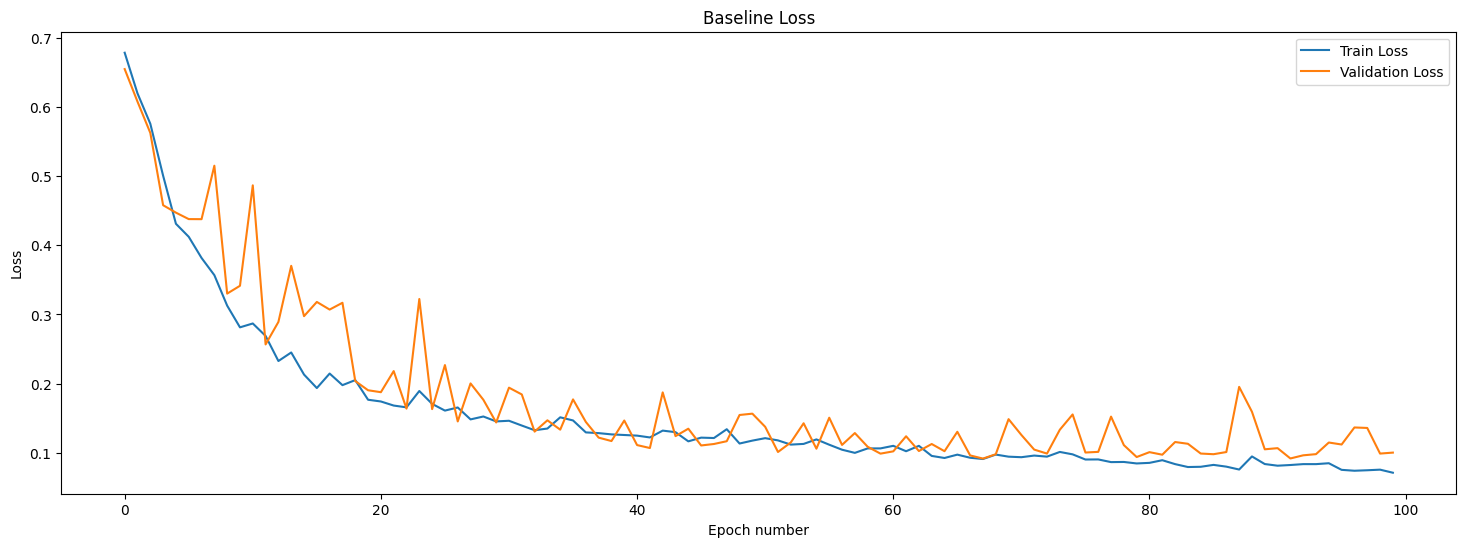

In [29]:
plt.plot(range(len(out_dict["train_loss"])), out_dict["train_loss"], label="Train Loss")
plt.plot(range(len(out_dict["validation_loss"])), out_dict["validation_loss"], label="Validation Loss")
plt.legend()
plt.xlabel('Epoch number')
plt.ylabel('Loss')
plt.title("Baseline Loss")
plt.show()

In [34]:
print("train loss: %f" % out_dict["train_loss"][len(out_dict["train_loss"])-1])
print('train iou: %f' % out_dict["train_iou"][len(out_dict["train_iou"])-1])
print('train accuracy: %f' % out_dict["train_accuracy"][len(out_dict["train_accuracy"])-1])
print("train sensitivity: %f" % out_dict["train_sensitivity"][len(out_dict["train_sensitivity"])-1])
print("train specificity: %f" % out_dict["train_specificity"][len(out_dict["train_specificity"])-1])
print("train dice: %f" % out_dict["train_dice"][len(out_dict["train_dice"])-1])

print("\nvalidation loss: %f" % out_dict["validation_loss"][len(out_dict["train_loss"])-1])
print('validation iou: %f' % out_dict["validation_iou"][len(out_dict["train_iou"])-1])
print('validation accuracy: %f' % out_dict["validation_accuracy"][len(out_dict["train_accuracy"])-1])
print("validation sensitivity: %f" % out_dict["validation_sensitivity"][len(out_dict["train_sensitivity"])-1])
print("validation specificity: %f" % out_dict["validation_specificity"][len(out_dict["train_specificity"])-1])
print("validation dice: %f" % out_dict["validation_dice"][len(out_dict["train_dice"])-1])

train loss: 0.071233
train iou: 0.895162
train accuracy: 0.970055
train sensitivity: 0.944577
train specificity: 0.978659
train dice: 0.944507

validation loss: 0.100312
validation iou: 0.870245
validation accuracy: 0.962071
validation sensitivity: 0.909489
validation specificity: 0.981647
validation dice: 0.930399


###  Performance measures


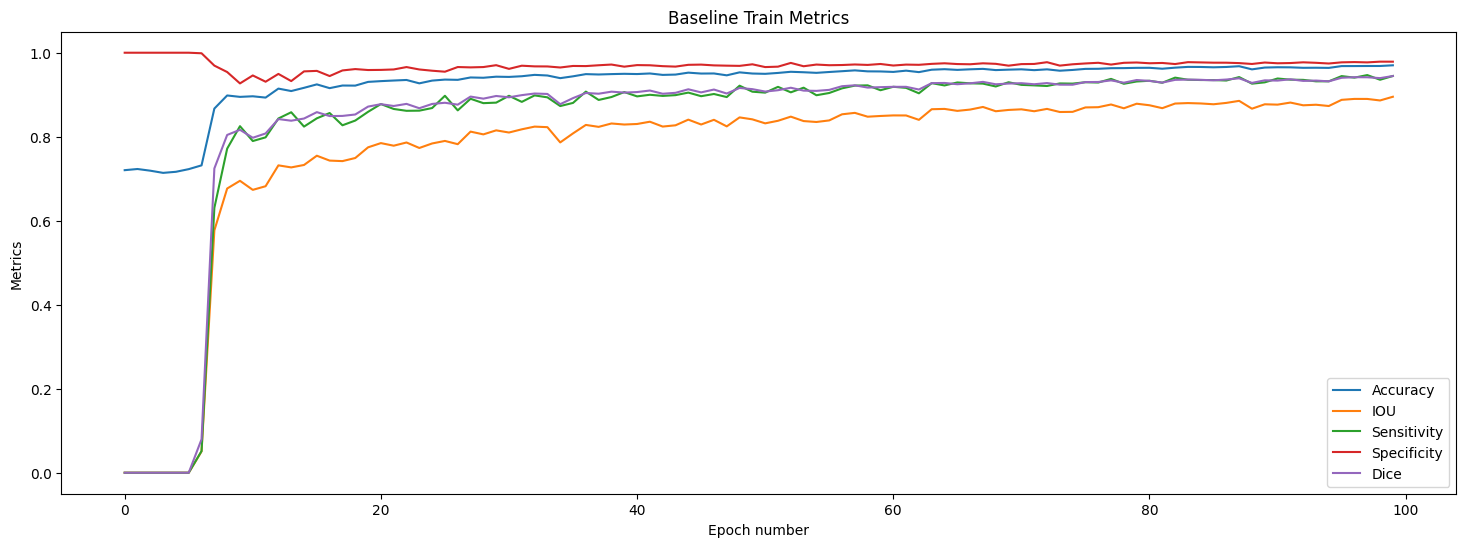

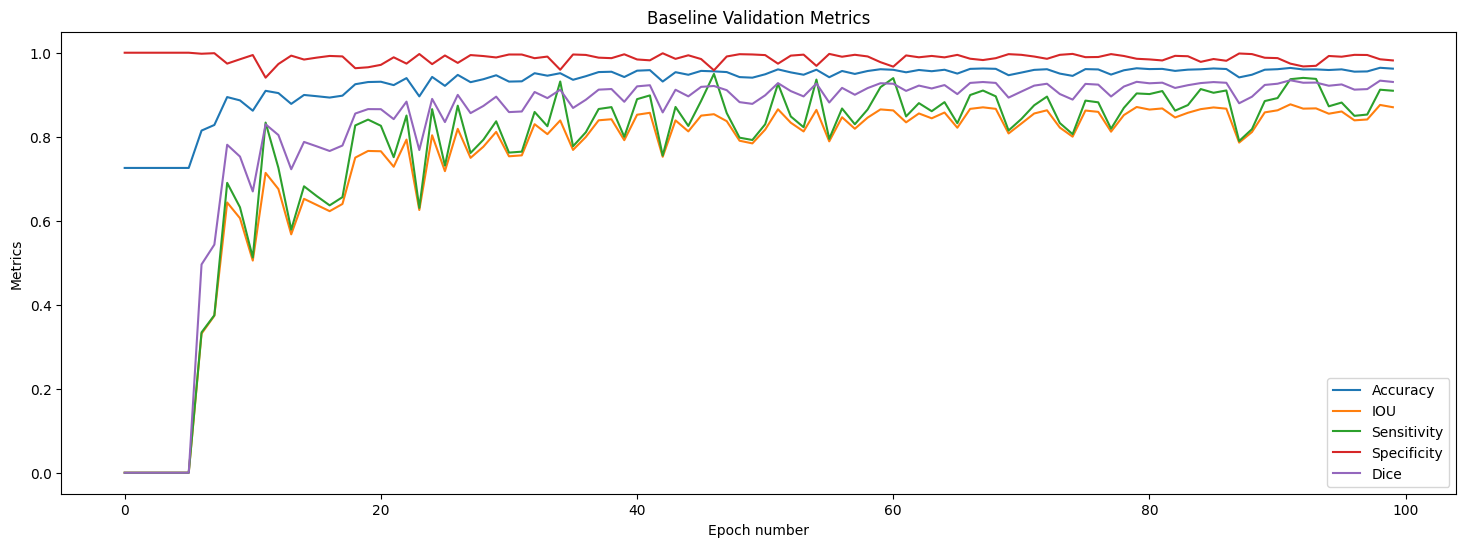

In [30]:
plt.plot(range(len(out_dict["train_accuracy"])), out_dict["train_accuracy"], label="Accuracy")
plt.plot(range(len(out_dict["train_iou"])), out_dict["train_iou"], label="IOU")
plt.plot(range(len(out_dict["train_sensitivity"])), out_dict["train_sensitivity"], label="Sensitivity")
plt.plot(range(len(out_dict["train_specificity"])), out_dict["train_specificity"], label="Specificity")
plt.plot(range(len(out_dict["train_dice"])), out_dict["train_dice"], label="Dice")
plt.legend()
plt.xlabel('Epoch number')
plt.ylabel('Metrics')
plt.title("Baseline Train Metrics")
plt.show()


plt.plot(range(len(out_dict["validation_accuracy"])), out_dict["validation_accuracy"], label="Accuracy")
plt.plot(range(len(out_dict["validation_iou"])), out_dict["validation_iou"], label="IOU")
plt.plot(range(len(out_dict["validation_sensitivity"])), out_dict["validation_sensitivity"], label="Sensitivity")
plt.plot(range(len(out_dict["validation_specificity"])), out_dict["validation_specificity"], label="Specificity")
plt.plot(range(len(out_dict["validation_dice"])), out_dict["validation_dice"], label="Dice")
plt.legend()
plt.xlabel('Epoch number')
plt.ylabel('Metrics')
plt.title("Baseline Validation Metrics")
plt.show()


### Test set

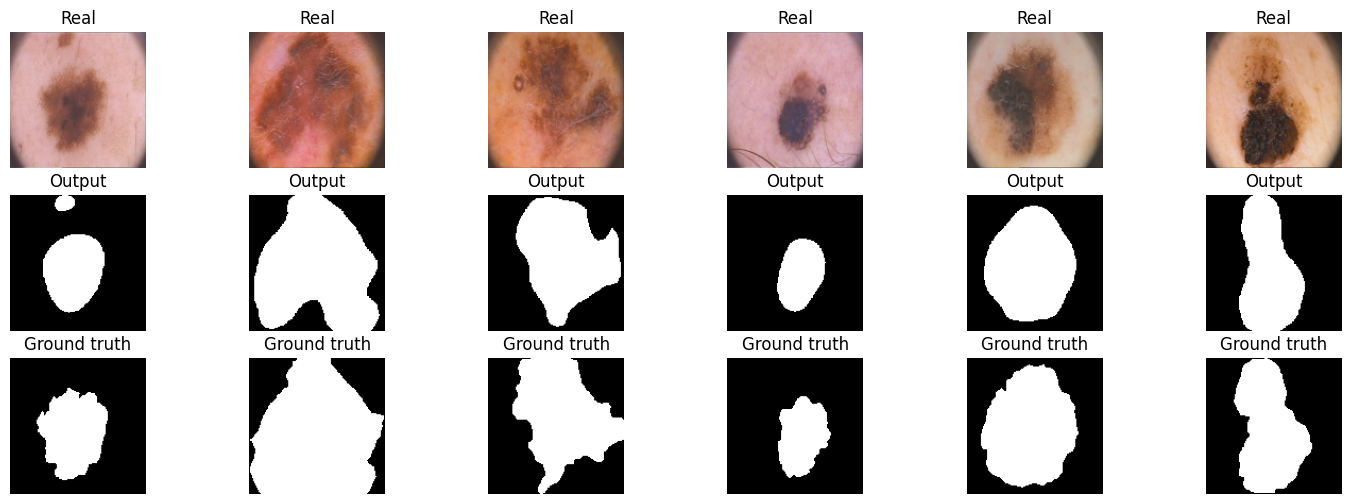

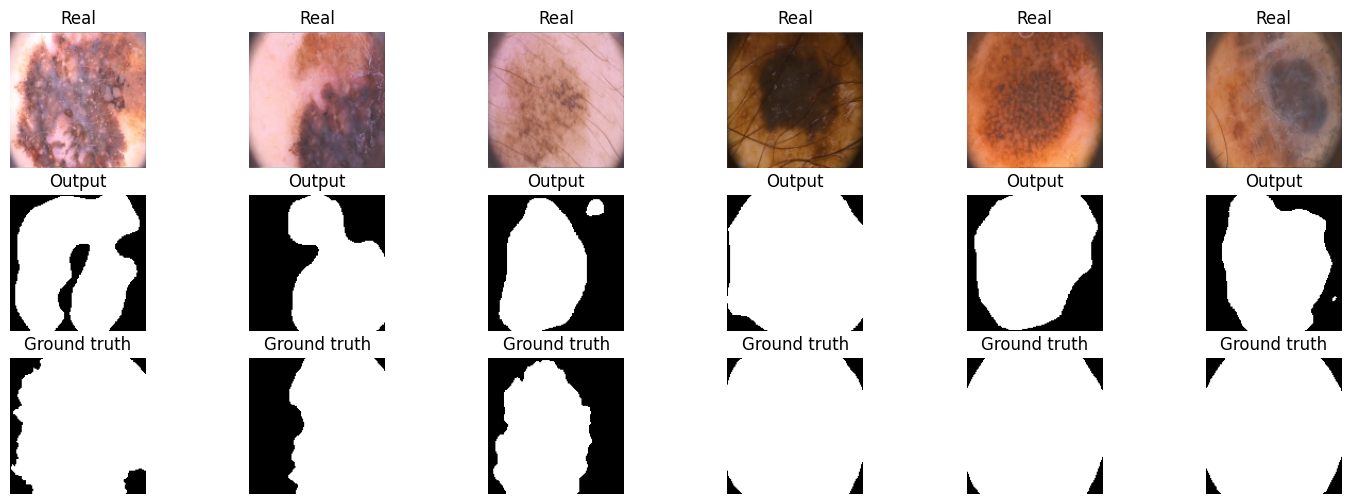

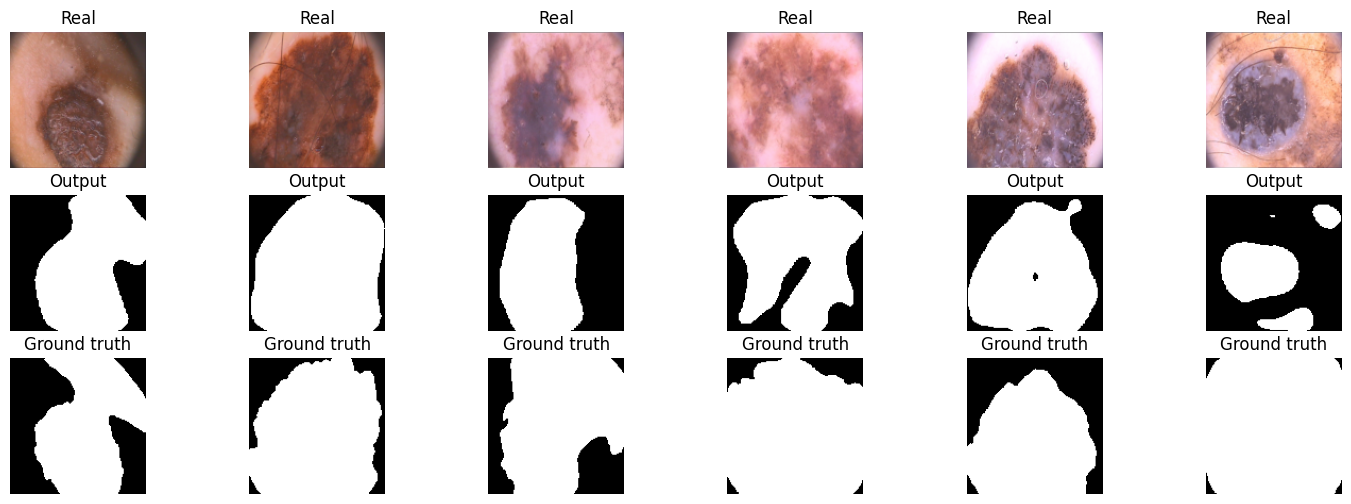

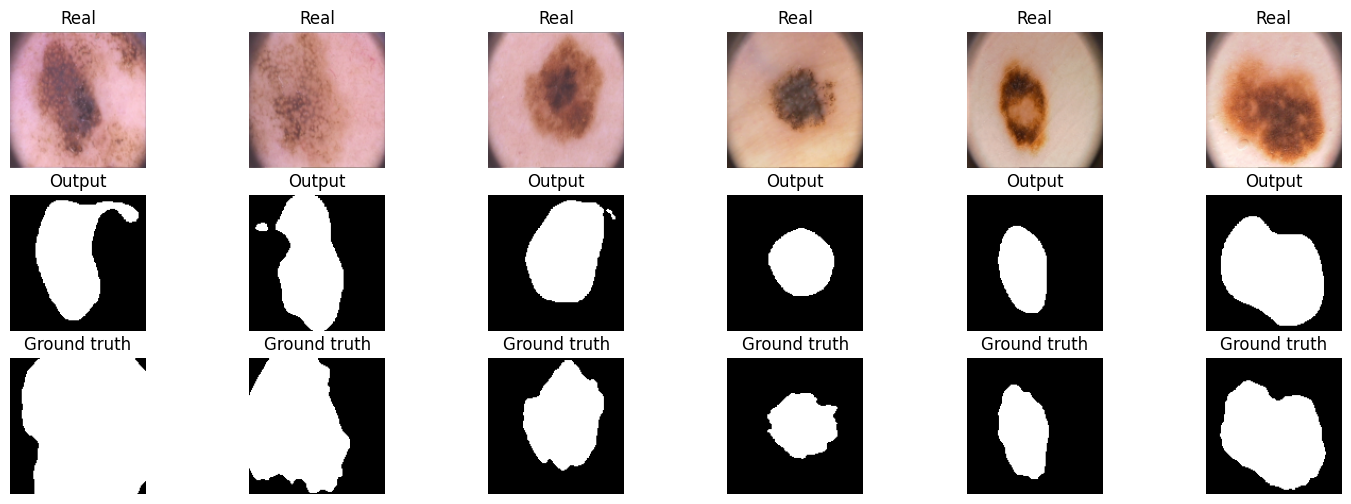

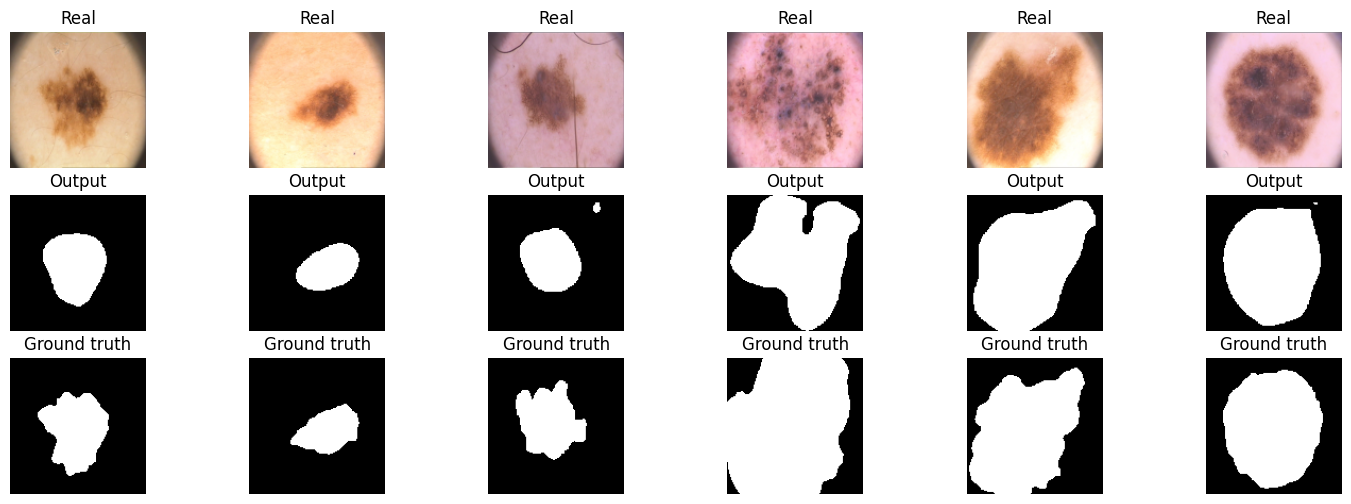

test iou: 0.770213
test accuracy: 0.862858
test sensitivity: 0.794218
test specificity: 0.949075
test dice: 0.868622


In [31]:
prediction, target, out_test = predict(model, test_loader)

In [32]:
import json

with open('baseline_out_test.json', 'w') as fp:
    json.dump(out_test, fp)

## UNet Model

In [9]:
def focal_loss(y_real, y_pred):
    y_pred = torch.clip(y_pred, min=-10, max=10)
    y_pred_s = torch.sigmoid(y_pred)
    return -torch.mean((((1-y_pred_s)**2) * y_real * torch.log(y_pred_s)) + ((1 - y_real) * torch.log(1-y_pred_s)))

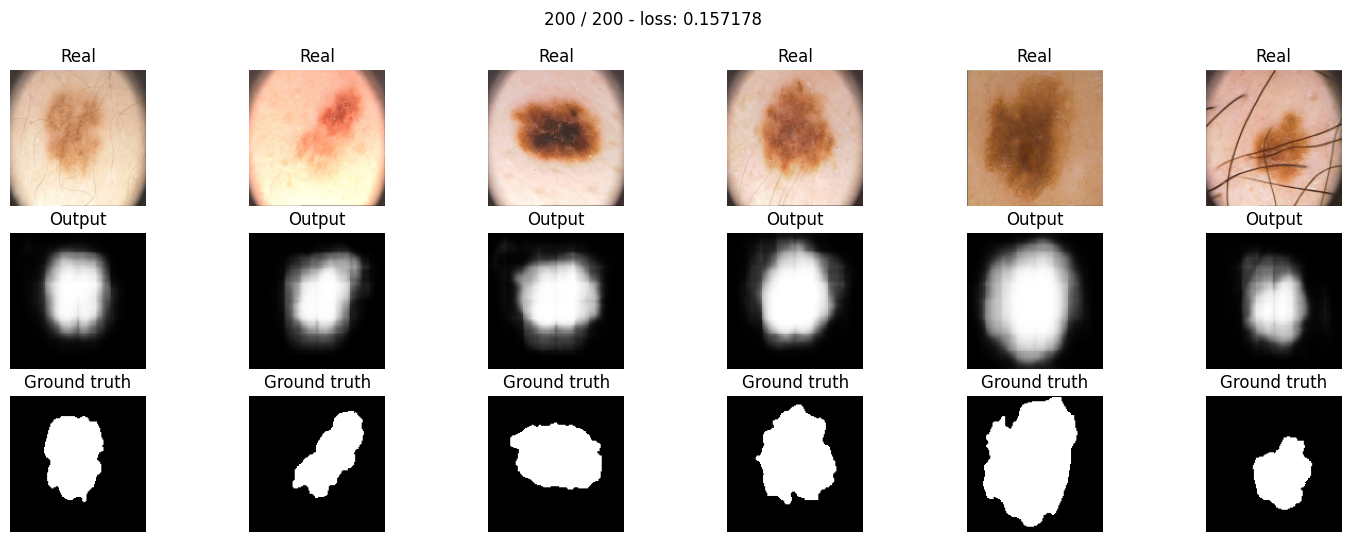

IOU is 0.7908335372509943, accuracy is 0.9409342447916667, sensitivity is 0.8337453373875379, specificity is 0.9800453032114572, dice is 0.8830130696296692


In [22]:
model = UNet().to(device)
out_dict = train(model, optim.Adam(model.parameters(), lr=1e-4), bce_loss, 200, train_loader, validation_loader)

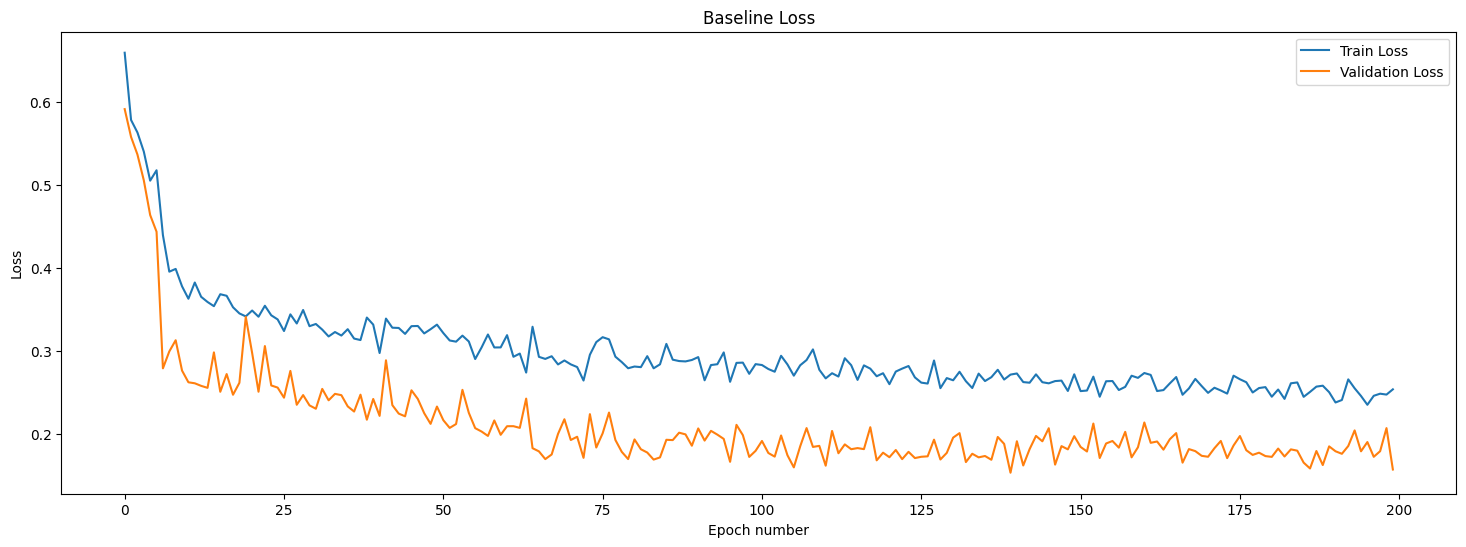

In [23]:
plt.plot(range(len(out_dict["train_loss"])), out_dict["train_loss"], label="Train Loss")
plt.plot(range(len(out_dict["validation_loss"])), out_dict["validation_loss"], label="Validation Loss")
plt.legend()
plt.xlabel('Epoch number')
plt.ylabel('Loss')
plt.title("Baseline Loss")
plt.show()

In [24]:
print("train loss: %f" % out_dict["train_loss"][len(out_dict["train_loss"])-1])
print('train iou: %f' % out_dict["train_iou"][len(out_dict["train_iou"])-1])
print('train accuracy: %f' % out_dict["train_accuracy"][len(out_dict["train_accuracy"])-1])
print("train sensitivity: %f" % out_dict["train_sensitivity"][len(out_dict["train_sensitivity"])-1])
print("train specificity: %f" % out_dict["train_specificity"][len(out_dict["train_specificity"])-1])
print("train dice: %f" % out_dict["train_dice"][len(out_dict["train_dice"])-1])

print("\nvalidation loss: %f" % out_dict["validation_loss"][len(out_dict["train_loss"])-1])
print('validation iou: %f' % out_dict["validation_iou"][len(out_dict["train_iou"])-1])
print('validation accuracy: %f' % out_dict["validation_accuracy"][len(out_dict["train_accuracy"])-1])
print("validation sensitivity: %f" % out_dict["validation_sensitivity"][len(out_dict["train_sensitivity"])-1])
print("validation specificity: %f" % out_dict["validation_specificity"][len(out_dict["train_specificity"])-1])
print("validation dice: %f" % out_dict["validation_dice"][len(out_dict["train_dice"])-1])

train loss: 0.253659
train iou: 0.643317
train accuracy: 0.888207
train sensitivity: 0.757747
train specificity: 0.929492
train dice: 0.779853

validation loss: 0.157178
validation iou: 0.790834
validation accuracy: 0.940934
validation sensitivity: 0.833745
validation specificity: 0.980045
validation dice: 0.883013


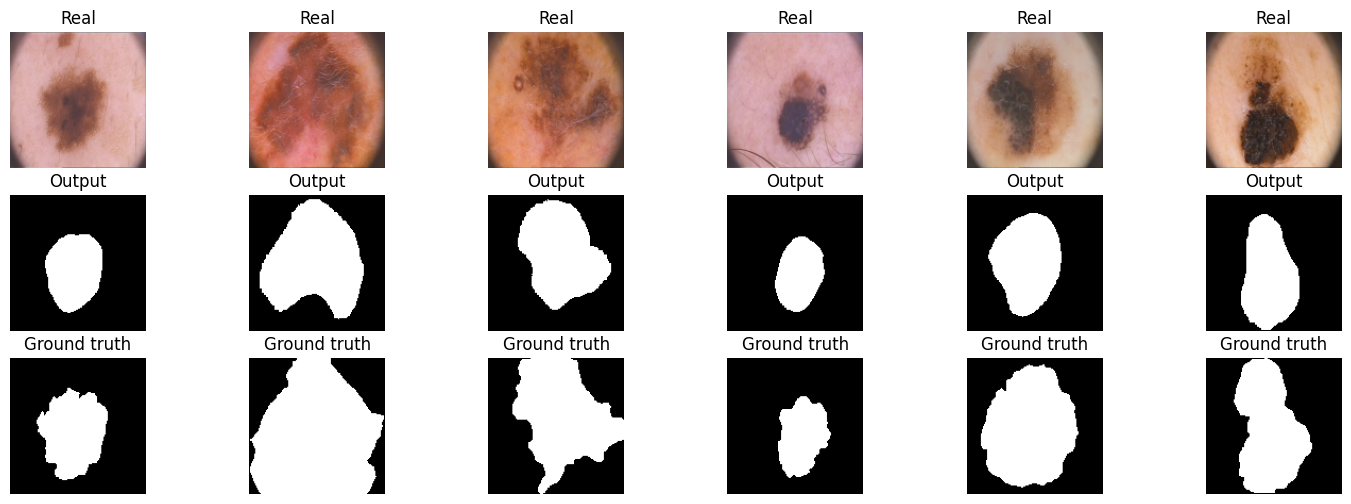

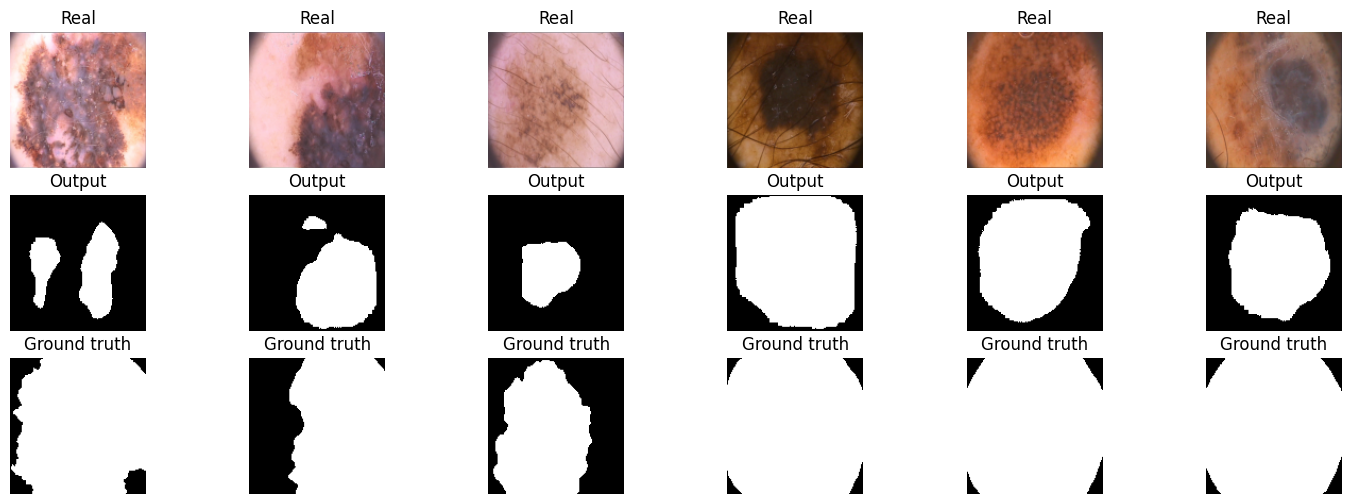

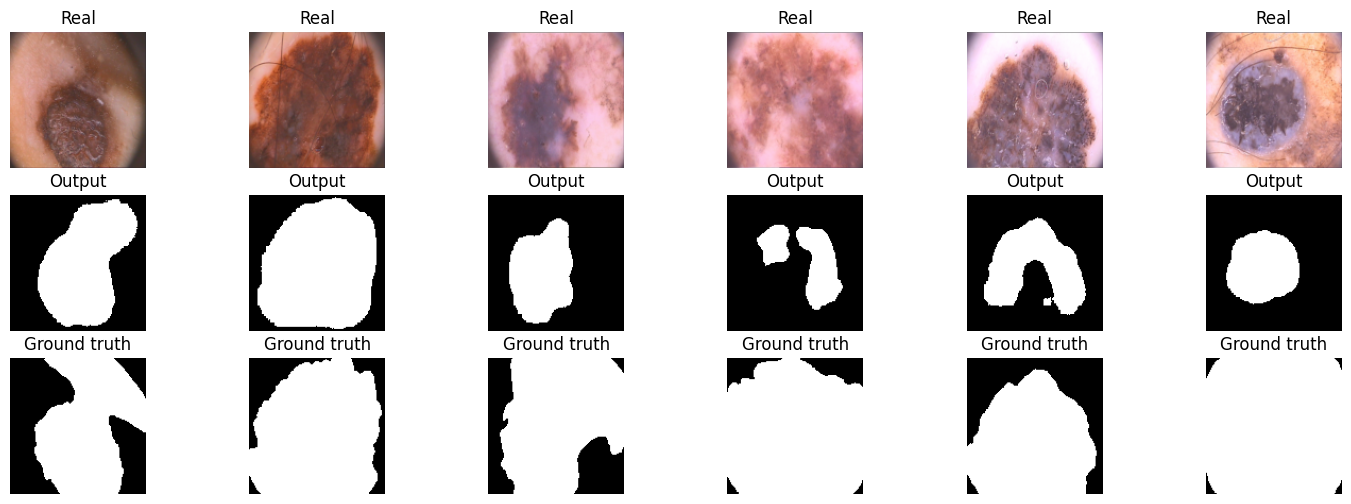

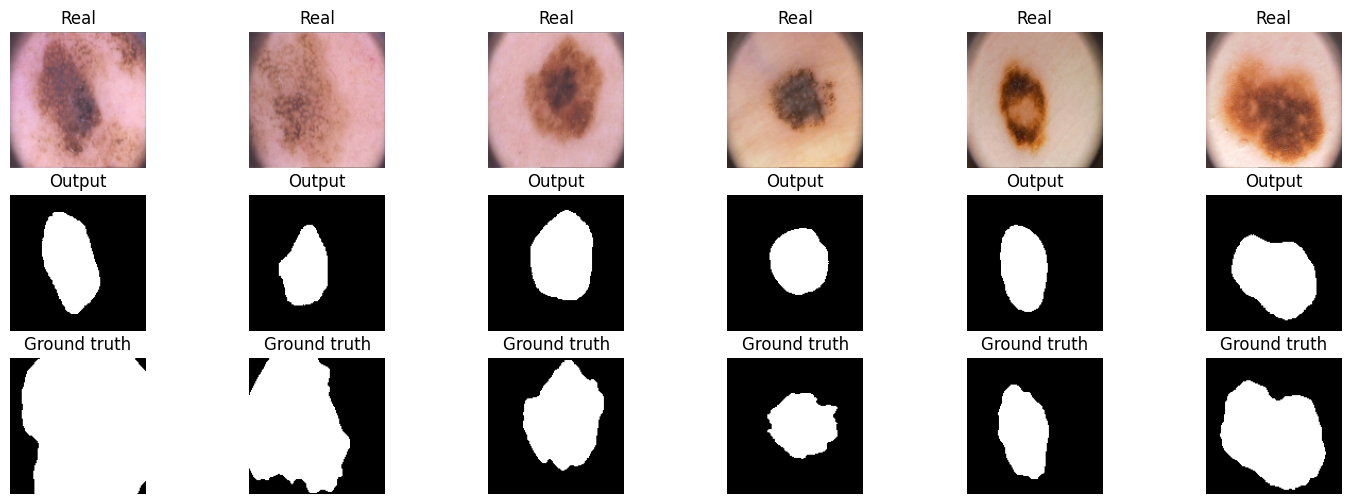

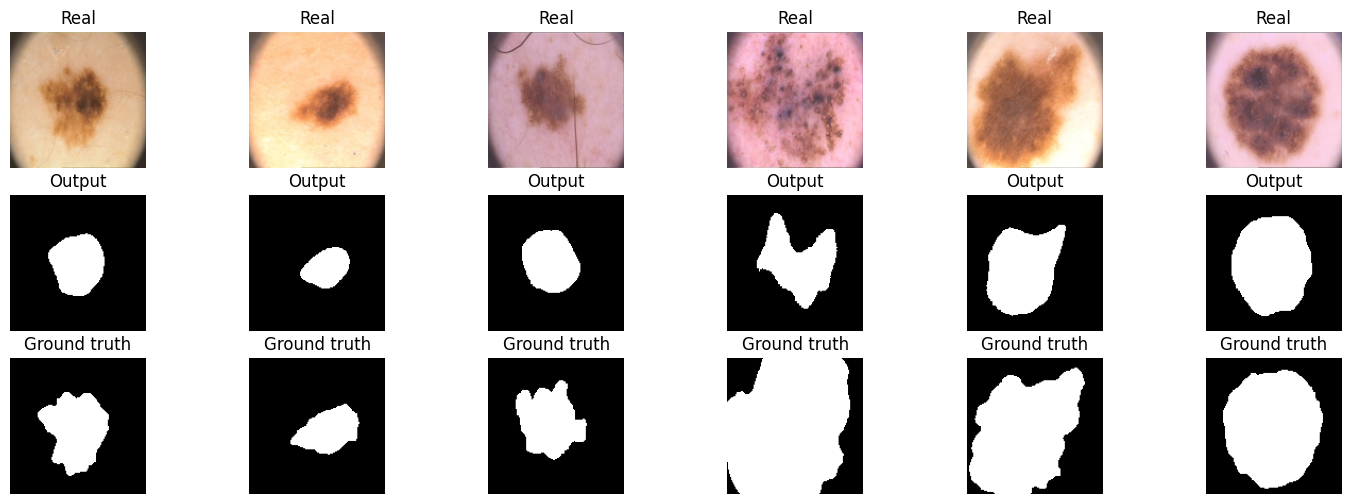

test iou: 0.527351
test accuracy: 0.725905
test sensitivity: 0.528793
test specificity: 0.996556
test dice: 0.686910


In [20]:
prediction, target, out_test = predict(model, test_loader)